# PyTorch Geometric (PyG) 实践教程

本 Notebook 提供 PyG 核心功能的可执行代码示例


## 1. 环境配置


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.utils import to_networkx
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

print(f"PyTorch 版本: {torch.__version__}")
print(f"设备: {'cuda' if torch.cuda.is_available() else 'cpu'}")


/home/hzx/anaconda3/envs/jupyterhub/lib/python3.11/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: Could not load this library: /home/hzx/anaconda3/envs/jupyterhub/lib/python3.11/site-packages/libpyg.so
  import torch_geometric.typing


PyTorch 版本: 2.11.0+cpu
设备: cpu


## 2. 创建简单图数据


In [2]:
# 创建包含4个节点的图，每个节点有2维特征
x = torch.tensor([[1.0, 2.0],
                  [3.0, 4.0],
                  [5.0, 6.0],
                  [7.0, 8.0]])

# 边连接：0->1, 1->2, 2->3, 3->0
edge_index = torch.tensor([[0, 1, 2, 3],
                           [1, 2, 3, 0]], dtype=torch.long)

data = Data(x=x, edge_index=edge_index)

print(f"节点数量: {data.num_nodes}")
print(f"边数量: {data.num_edges}")
print(f"节点特征维度: {data.num_node_features}")
print(f"是否有向图: {not data.is_undirected()}")

节点数量: 4
边数量: 4
节点特征维度: 2
是否有向图: True


## 3. 可视化图结构


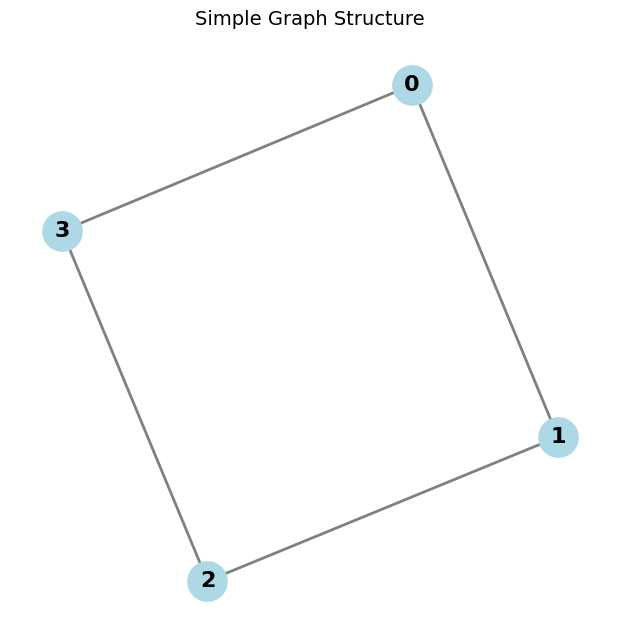

In [23]:
# 将 PyG 图转换为 NetworkX 并可视化
G = to_networkx(data, to_undirected=True)

plt.figure(figsize=(6, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightblue',
        node_size=800, font_size=16, font_weight='bold',
        edge_color='gray', width=2, arrows=False)
plt.title("Simple Graph Structure", fontsize=14)
plt.axis('off')
plt.show()

## 4. 自定义消息传递层


In [ ]:
from torch_geometric.nn import MessagePassing


class CustomConv(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='add')  # 使用求和聚合
        self.lin = nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index):
        # 1. 特征变换
        x = self.lin(x)
        # 2. 消息传递
        return self.propagate(edge_index, x=x)

    def message(self, x_j):
        # 从邻居 j 发送的消息
        return x_j

    def update(self, aggr_out):
        # 更新节点特征
        return aggr_out


# 测试自定义层
conv = CustomConv(2, 4)
out = conv(data.x, data.edge_index)
print(f"输入特征形状: {data.x.shape}")
print(f"输出特征形状: {out.shape}")

输入特征形状: torch.Size([4, 2])
输出特征形状: torch.Size([4, 4])


## 5. 图卷积网络 (GCN)


In [5]:
from torch_geometric.nn import GCNConv


class GCN(nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes):
        super().__init__()
        self.conv1 = GCNConv(num_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x


# 创建模型并测试
model = GCN(num_features=2, hidden_dim=16, num_classes=4)
model.eval()
with torch.no_grad():
    out = model(data)
print(f"GCN 输出形状: {out.shape}")
print(f"模型参数量: {sum(p.numel() for p in model.parameters())}")

GCN 输出形状: torch.Size([4, 4])
模型参数量: 116


## 6. 在 Cora 数据集上训练 GCN


In [6]:
import requests
import os
from pathlib import Path

# 配置代理
proxies = {
    'http': 'socks5h://127.0.0.1:10808',
    'https': 'socks5h://127.0.0.1:10808'
}

# Cora 数据集的下载链接
url = "https://github.com/kimiyoung/planetoid/raw/master/data/ind.cora.x"
save_dir = Path("/tmp/Cora/raw")
save_dir.mkdir(parents=True, exist_ok=True)

# 需要下载的文件列表
files = [
    "ind.cora.x",
    "ind.cora.tx",
    "ind.cora.allx",
    "ind.cora.y",
    "ind.cora.ty",
    "ind.cora.ally",
    "ind.cora.graph",
    "ind.cora.test.index"
]

print("开始下载 Cora 数据集文件...")
base_url = "https://github.com/kimiyoung/planetoid/raw/master/data"

for filename in files:
    file_path = save_dir / filename
    if file_path.exists():
        print(f"✓ {filename} 已存在，跳过")
        continue

    try:
        print(f"下载 {filename}...", end=" ")
        response = requests.get(
            f"{base_url}/{filename}", proxies=proxies, timeout=30)
        response.raise_for_status()

        with open(file_path, 'wb') as f:
            f.write(response.content)
        print("✓")
    except Exception as e:
        print(f"✗ 失败: {e}")

print("\n现在重新加载数据集:")

开始下载 Cora 数据集文件...
✓ ind.cora.x 已存在，跳过
✓ ind.cora.tx 已存在，跳过
✓ ind.cora.allx 已存在，跳过
✓ ind.cora.y 已存在，跳过
✓ ind.cora.ty 已存在，跳过
✓ ind.cora.ally 已存在，跳过
✓ ind.cora.graph 已存在，跳过
✓ ind.cora.test.index 已存在，跳过

现在重新加载数据集:


In [25]:
from torch_geometric.datasets import Planetoid

# 加载 Cora 数据集
dataset = Planetoid(root='/tmp', name='Cora')
cora_data = dataset[0]

print(f"数据集: {dataset}")
print(f"图数量: {len(dataset)}")
print(f"类别数: {dataset.num_classes}")
print(f"节点特征维度: {dataset.num_node_features}")
print(f"节点数: {cora_data.num_nodes}")
print(f"边数: {cora_data.num_edges}")
print(f"训练节点: {cora_data.train_mask.sum().item()}")
print(f"验证节点: {cora_data.val_mask.sum().item()}")
print(f"测试节点: {cora_data.test_mask.sum().item()}")

数据集: Cora()
图数量: 1
类别数: 7
节点特征维度: 1433
节点数: 2708
边数: 10556
训练节点: 140
验证节点: 500
测试节点: 1000


Processing...
/home/hzx/anaconda3/envs/jupyterhub/lib/python3.11/site-packages/torch_geometric/io/planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
/home/hzx/anaconda3/envs/jupyterhub/lib/python3.11/site-packages/torch_geometric/io/planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
/home/hzx/anaconda3/envs/jupyterhub/lib/python3.11/site-packages/torch_geometric/io/planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
/h

In [8]:
# 创建 GCN 模型用于节点分类
model = GCN(num_features=dataset.num_node_features,
            hidden_dim=16,
            num_classes=dataset.num_classes)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)


def train():
    model.train()
    optimizer.zero_grad()
    out = model(cora_data)
    loss = F.cross_entropy(out[cora_data.train_mask],
                           cora_data.y[cora_data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()


def test():
    model.eval()
    out = model(cora_data)
    pred = out.argmax(dim=1)

    accs = []
    for mask in [cora_data.train_mask, cora_data.val_mask, cora_data.test_mask]:
        correct = pred[mask] == cora_data.y[mask]
        accs.append(correct.sum().item() / mask.sum().item())
    return accs


# 训练模型（减少 epoch 数以加快速度）
losses = []
train_accs = []
val_accs = []
test_accs = []

for epoch in range(1, 101):
    loss = train()
    train_acc, val_acc, test_acc = test()
    losses.append(loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    test_accs.append(test_acc)

    if epoch % 20 == 0:
        print(f'Epoch {epoch:03d}, Loss: {loss:.4f}, '
              f'Train: {train_acc:.4f}, Val: {val_acc:.4f}, Test: {test_acc:.4f}')

print(f'\n最终测试准确率: {test_accs[-1]:.4f}')

Epoch 020, Loss: 0.3189, Train: 1.0000, Val: 0.7480, Test: 0.7610
Epoch 040, Loss: 0.0702, Train: 1.0000, Val: 0.7640, Test: 0.7710
Epoch 060, Loss: 0.0403, Train: 1.0000, Val: 0.7660, Test: 0.7820
Epoch 080, Loss: 0.0351, Train: 1.0000, Val: 0.7680, Test: 0.7710
Epoch 100, Loss: 0.0520, Train: 1.0000, Val: 0.7700, Test: 0.7800

最终测试准确率: 0.7800


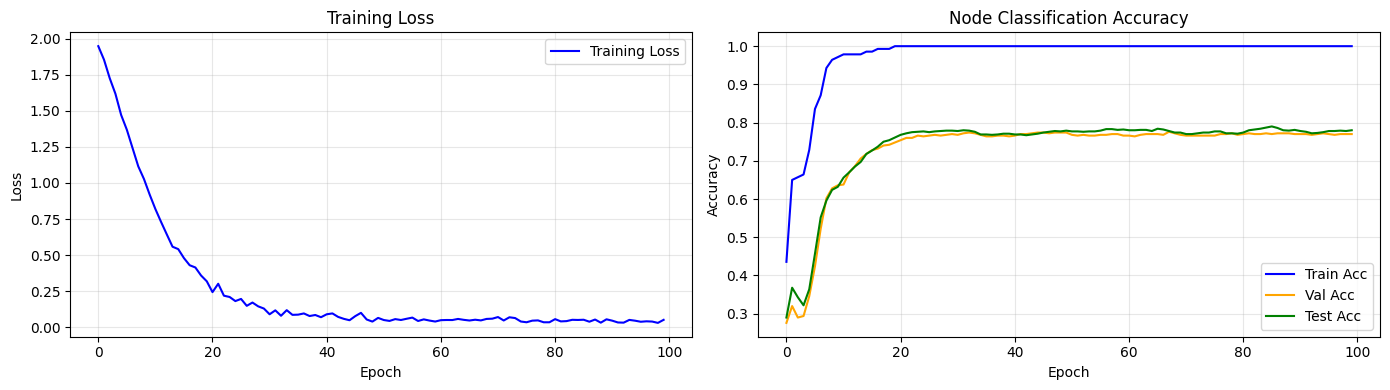

In [9]:
# 可视化训练过程
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(losses, label='Training Loss', color='blue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(train_accs, label='Train Acc', color='blue')
ax2.plot(val_accs, label='Val Acc', color='orange')
ax2.plot(test_accs, label='Test Acc', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Node Classification Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 图注意力网络 (GAT)


In [10]:
from torch_geometric.nn import GATConv
import torch.nn.functional as F
import torch.nn as nn


class GAT(nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes, heads=8):
        super().__init__()
        self.conv1 = GATConv(num_features, hidden_dim,
                             heads=heads, dropout=0.6)
        self.conv2 = GATConv(hidden_dim * heads, num_classes, heads=1,
                             concat=False, dropout=0.6)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.dropout(x, p=0.6, training=self.training)
        x = F.elu(self.conv1(x, edge_index))  # 改这里
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv2(x, edge_index)
        return x


# 创建并训练 GAT 模型
gat_model = GAT(num_features=dataset.num_node_features,
                hidden_dim=8,
                num_classes=dataset.num_classes,
                heads=8)

optimizer = torch.optim.Adam(
    gat_model.parameters(), lr=0.005, weight_decay=5e-4)

# 训练 GAT
gat_losses = []
gat_test_accs = []

for epoch in range(1, 101):
    gat_model.train()
    optimizer.zero_grad()
    out = gat_model(cora_data)
    loss = F.cross_entropy(out[cora_data.train_mask],
                           cora_data.y[cora_data.train_mask])
    loss.backward()
    optimizer.step()
    gat_losses.append(loss.item())

    if epoch % 20 == 0:
        gat_model.eval()
        out = gat_model(cora_data)
        pred = out.argmax(dim=1)
        test_acc = (pred[cora_data.test_mask] == cora_data.y[cora_data.test_mask]).sum(
        ).item() / cora_data.test_mask.sum().item()
        gat_test_accs.append(test_acc)
        print(f'Epoch {epoch:03d}, Loss: {loss:.4f}, Test: {test_acc:.4f}')

# 最终测试
gat_model.eval()
out = gat_model(cora_data)
pred = out.argmax(dim=1)
test_acc = (pred[cora_data.test_mask] == cora_data.y[cora_data.test_mask]).sum(
).item() / cora_data.test_mask.sum().item()
print(f'\nGAT 最终测试准确率: {test_acc:.4f}')

Epoch 020, Loss: 0.8042, Test: 0.8120
Epoch 040, Loss: 0.6069, Test: 0.8060
Epoch 060, Loss: 0.5095, Test: 0.8020
Epoch 080, Loss: 0.4297, Test: 0.8000
Epoch 100, Loss: 0.4326, Test: 0.8010

GAT 最终测试准确率: 0.8010


## 8. GraphSAGE


In [11]:
from torch_geometric.nn import SAGEConv


class GraphSAGE(nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes):
        super().__init__()
        self.conv1 = SAGEConv(num_features, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x


# 训练 GraphSAGE
sage_model = GraphSAGE(num_features=dataset.num_node_features,
                       hidden_dim=16,
                       num_classes=dataset.num_classes)

optimizer = torch.optim.Adam(
    sage_model.parameters(), lr=0.01, weight_decay=5e-4)

for epoch in range(1, 101):
    sage_model.train()
    optimizer.zero_grad()
    out = sage_model(cora_data)
    loss = F.cross_entropy(out[cora_data.train_mask],
                           cora_data.y[cora_data.train_mask])
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        sage_model.eval()
        out = sage_model(cora_data)
        pred = out.argmax(dim=1)
        test_acc = (pred[cora_data.test_mask] == cora_data.y[cora_data.test_mask]).sum(
        ).item() / cora_data.test_mask.sum().item()
        print(f'Epoch {epoch:03d}, Loss: {loss:.4f}, Test: {test_acc:.4f}')

sage_model.eval()
out = sage_model(cora_data)
pred = out.argmax(dim=1)
test_acc = (pred[cora_data.test_mask] == cora_data.y[cora_data.test_mask]).sum(
).item() / cora_data.test_mask.sum().item()
print(f'\nGraphSAGE 最终测试准确率: {test_acc:.4f}')

Epoch 020, Loss: 0.0703, Test: 0.7610
Epoch 040, Loss: 0.0254, Test: 0.7760
Epoch 060, Loss: 0.0149, Test: 0.7710
Epoch 080, Loss: 0.0222, Test: 0.7890
Epoch 100, Loss: 0.0119, Test: 0.7800

GraphSAGE 最终测试准确率: 0.7800


## 9. 图分类任务


In [12]:
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool

# 加载 MUTAG 数据集（分子图分类）
dataset = TUDataset(root='/tmp/MUTAG', name='MUTAG')

print(f"数据集: {dataset}")
print(f"图数量: {len(dataset)}")
print(f"类别数: {dataset.num_classes}")
print(f"节点特征维度: {dataset.num_node_features}")

# 查看第一个图
sample = dataset[0]
print(f"\n示例图信息:")
print(f"节点数: {sample.num_nodes}")
print(f"边数: {sample.num_edges}")
print(f"标签: {sample.y.item()}")

数据集: MUTAG(188)
图数量: 188
类别数: 2
节点特征维度: 7

示例图信息:
节点数: 17
边数: 38
标签: 1


In [13]:
# 划分训练集和测试集
torch.manual_seed(42)
dataset = dataset.shuffle()
train_dataset = dataset[:150]
test_dataset = dataset[150:]

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"训练集: {len(train_dataset)} 个图")
print(f"测试集: {len(test_dataset)} 个图")

训练集: 150 个图
测试集: 38 个图


In [14]:
# 图分类模型
class GraphClassifier(nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes):
        super().__init__()
        self.conv1 = GCNConv(num_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.lin = nn.Linear(hidden_dim, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        x = self.conv3(x, edge_index).relu()

        # 全局平均池化
        x = global_mean_pool(x, batch)

        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)
        return x


model = GraphClassifier(num_features=dataset.num_node_features,
                        hidden_dim=64,
                        num_classes=dataset.num_classes)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


def train_epoch():
    model.train()
    total_loss = 0
    for data in train_loader:
        optimizer.zero_grad()
        out = model(data)
        loss = F.cross_entropy(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(train_loader.dataset)


def test_epoch(loader):
    model.eval()
    correct = 0
    for data in loader:
        out = model(data)
        pred = out.argmax(dim=1)
        correct += (pred == data.y).sum().item()
    return correct / len(loader.dataset)


# 训练模型
for epoch in range(1, 101):
    loss = train_epoch()
    if epoch % 20 == 0:
        train_acc = test_epoch(train_loader)
        test_acc = test_epoch(test_loader)
        print(f'Epoch {epoch:03d}, Loss: {loss:.4f}, '
              f'Train: {train_acc:.4f}, Test: {test_acc:.4f}')

# 最终评估
train_acc = test_epoch(train_loader)
test_acc = test_epoch(test_loader)
print(f'\n最终结果 - 训练准确率: {train_acc:.4f}, 测试准确率: {test_acc:.4f}')

Epoch 020, Loss: 0.5290, Train: 0.7800, Test: 0.7105
Epoch 040, Loss: 0.4611, Train: 0.7667, Test: 0.6579
Epoch 060, Loss: 0.4623, Train: 0.7600, Test: 0.6579
Epoch 080, Loss: 0.4559, Train: 0.7933, Test: 0.6316
Epoch 100, Loss: 0.4846, Train: 0.7733, Test: 0.7105

最终结果 - 训练准确率: 0.7733, 测试准确率: 0.7105


## 10. 边索引操作与工具函数


In [15]:
from torch_geometric.utils import (add_self_loops, remove_self_loops,
                                   is_undirected, contains_self_loops,
                                   to_undirected)

# 创建测试边索引
edge_index = torch.tensor([[0, 1, 2],
                           [1, 2, 0]], dtype=torch.long)

print("原始边索引:")
print(edge_index)
print(f"是否无向: {is_undirected(edge_index)}")
print(f"包含自环: {contains_self_loops(edge_index)}")

# 添加自环
edge_index_with_loops, _ = add_self_loops(edge_index, num_nodes=3)
print(f"\n添加自环后:")
print(edge_index_with_loops)
print(f"包含自环: {contains_self_loops(edge_index_with_loops)}")

# 转换为无向图
undirected_edge_index = to_undirected(edge_index)
print(f"\n转换为无向图:")
print(undirected_edge_index)
print(f"是否无向: {is_undirected(undirected_edge_index)}")

原始边索引:
tensor([[0, 1, 2],
        [1, 2, 0]])
是否无向: False
包含自环: False

添加自环后:
tensor([[0, 1, 2, 0, 1, 2],
        [1, 2, 0, 0, 1, 2]])
包含自环: True

转换为无向图:
tensor([[0, 0, 1, 1, 2, 2],
        [1, 2, 0, 2, 0, 1]])
是否无向: True


## 11. 邻居采样（NeighborLoader）


In [17]:
# 完整的多层邻居采样演示
def multilayer_neighbor_sample(data, seed_nodes, num_neighbors_per_layer):
    """
    多层邻居采样
    seed_nodes: 种子节点
    num_neighbors_per_layer: 每层采样的邻居数，如 [10, 5] 表示第1层10个，第2层5个
    """
    edge_index = data.edge_index
    sampled_nodes = set(seed_nodes.tolist())

    current_layer = seed_nodes
    for layer_idx, num_neighbors in enumerate(num_neighbors_per_layer):
        next_layer = []

        for node in current_layer:
            # 找邻居
            neighbors = edge_index[1][edge_index[0] == node]

            # 采样
            if len(neighbors) > num_neighbors:
                perm = torch.randperm(len(neighbors))[:num_neighbors]
                sampled = neighbors[perm]
            else:
                sampled = neighbors

            next_layer.extend(sampled.tolist())
            sampled_nodes.update(sampled.tolist())

        current_layer = torch.tensor(list(set(next_layer)))
        print(f"  第 {layer_idx+1} 层采样: {len(current_layer)} 个节点")

    return list(sampled_nodes)


# 演示 2 层采样（模拟 NeighborLoader）
train_nodes = cora_data.train_mask.nonzero(
    as_tuple=True)[0][:128]  # 取 128 个作为批次

print(f"原始图: {cora_data.num_nodes} 节点, {cora_data.num_edges} 边")
print(f"\n批次大小: {len(train_nodes)} 个种子节点")
print("采样策略: [10, 5] (第1层10个邻居, 第2层5个邻居)")

sampled = multilayer_neighbor_sample(cora_data, train_nodes, [10, 5])

print(f"\n采样子图总节点数: {len(sampled)}")
print(f"采样率: {len(sampled)/cora_data.num_nodes*100:.1f}%")

原始图: 2708 节点, 10556 边

批次大小: 128 个种子节点
采样策略: [10, 5] (第1层10个邻居, 第2层5个邻居)
  第 1 层采样: 443 个节点
  第 2 层采样: 938 个节点

采样子图总节点数: 1090
采样率: 40.3%


## 12. 模型对比总结


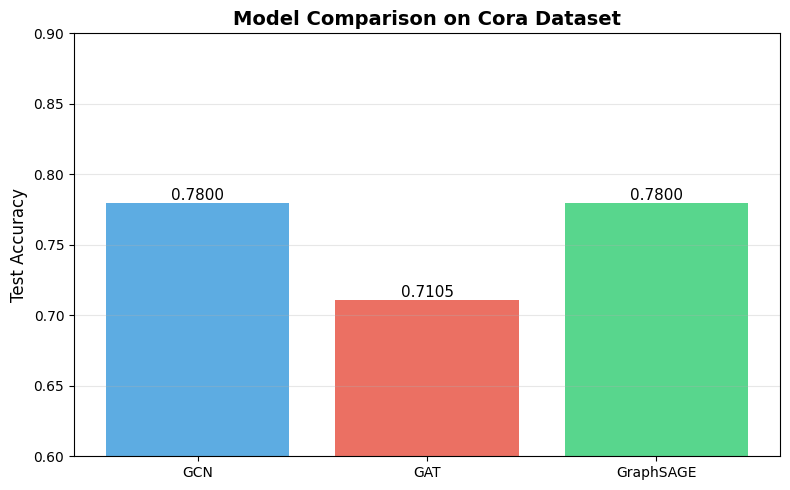


模型性能对比:
GCN: 0.7800
GAT: 0.7105
GraphSAGE: 0.7800


In [19]:
# 对比不同模型在 Cora 上的表现
models_comparison = {
    'GCN': test_accs[-1],
    'GAT': test_acc,  # GAT 的最终准确率
}

# 添加 GraphSAGE 结果
sage_model.eval()
out = sage_model(cora_data)
pred = out.argmax(dim=1)
sage_acc = (pred[cora_data.test_mask] == cora_data.y[cora_data.test_mask]).sum(
).item() / cora_data.test_mask.sum().item()
models_comparison['GraphSAGE'] = sage_acc

# 可视化对比
plt.figure(figsize=(8, 5))
models = list(models_comparison.keys())
accs = list(models_comparison.values())

bars = plt.bar(models, accs, color=[
               '#3498db', '#e74c3c', '#2ecc71'], alpha=0.8)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Model Comparison on Cora Dataset', fontsize=14, fontweight='bold')
plt.ylim([0.6, 0.9])
plt.grid(axis='y', alpha=0.3)

# 在柱状图上显示数值
for bar, acc in zip(bars, accs):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.4f}',
             ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

print("\n模型性能对比:")
for model_name, acc in models_comparison.items():
    print(f"{model_name}: {acc:.4f}")

## 总结

本 Notebook 演示了 PyG 的核心功能：

1. **数据结构**: Data 对象与边索引表示
2. **消息传递**: 自定义 MessagePassing 层
3. **常用模型**: GCN, GAT, GraphSAGE
4. **节点分类**: 在 Cora 数据集上的应用
5. **图分类**: 在 MUTAG 数据集上的分子分类
6. **数据加载**: DataLoader 和 NeighborLoader

继续探索更多 PyG 功能，构建强大的图神经网络！
